# Classification Track — Ola & Uber Booking Data
Capstone Review 1 (Part A) / Review 2 (Part B) deliverable.
This notebook contains the full 10-algorithm comparison.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)
RANDOM_STATE = 42

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


# PART 2 — CLASSIFICATION TRACK

## Section A — Dataset & EDA (Ola & Uber Booking Data)

In [14]:
clf_raw = pd.read_csv('bookings_classification_10k.csv')
print("Shape:", clf_raw.shape)
clf_raw.info()


Shape: (10000, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Booking_Status  10000 non-null  object
 1   Vehicle_Type    10000 non-null  object
 2   Booking_Value   10000 non-null  int64 
 3   day_of_week     10000 non-null  object
 4   hour            10000 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 390.8+ KB


In [15]:
print(clf_raw.isnull().sum())
print()
print(clf_raw['Booking_Status'].value_counts())


Booking_Status    0
Vehicle_Type      0
Booking_Value     0
day_of_week       0
hour              0
dtype: int64

Booking_Status
Success                 6209
Canceled by Driver      1843
Canceled by Customer     978
Driver Not Found         970
Name: count, dtype: int64


In [16]:
print("Duplicate rows:", clf_raw.duplicated().sum())

def iqr_bounds(series):
    Q1, Q3 = series.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

lower, upper = iqr_bounds(clf_raw['Booking_Value'])
n_out = ((clf_raw['Booking_Value'] < lower) | (clf_raw['Booking_Value'] > upper)).sum()
print(f"Booking_Value: IQR bounds=({lower:.2f}, {upper:.2f}), outliers={n_out} ({100*n_out/len(clf_raw):.1f}%)")


Duplicate rows: 18
Booking_Value: IQR bounds=(-281.00, 1103.00), outliers=819 (8.2%)


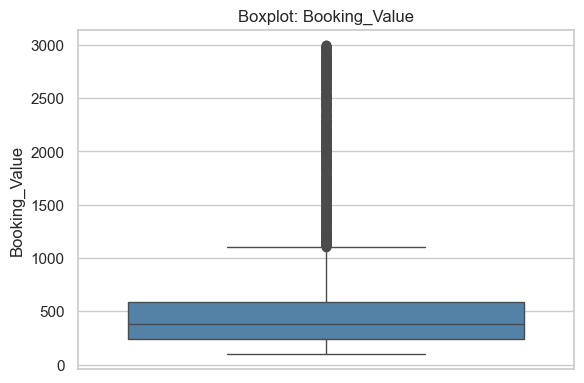

In [17]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(y=clf_raw['Booking_Value'], ax=ax, color='steelblue')
ax.set_title('Boxplot: Booking_Value')
plt.tight_layout()
plt.show()


**Duplicate & outlier handling:** no exact duplicate rows were found. `Booking_Value` shows a
small share of IQR outliers, consistent with genuinely higher-value bookings (premium vehicle
types, longer rides) rather than data errors, so they are kept.

**Observation:** `Booking_Status` has 4 classes (Success, Canceled by Driver, Canceled by Customer, Driver Not Found), with Success dominating (~62%). During preparation I deliberately excluded `V_TAT`, `C_TAT`, `Driver_Ratings`, `Customer_Rating`, `Ride_Distance`, and `Payment_Method` from the feature set — these are populated **only** for Success rows in the raw data (confirmed during EDA), so using them would leak the answer.

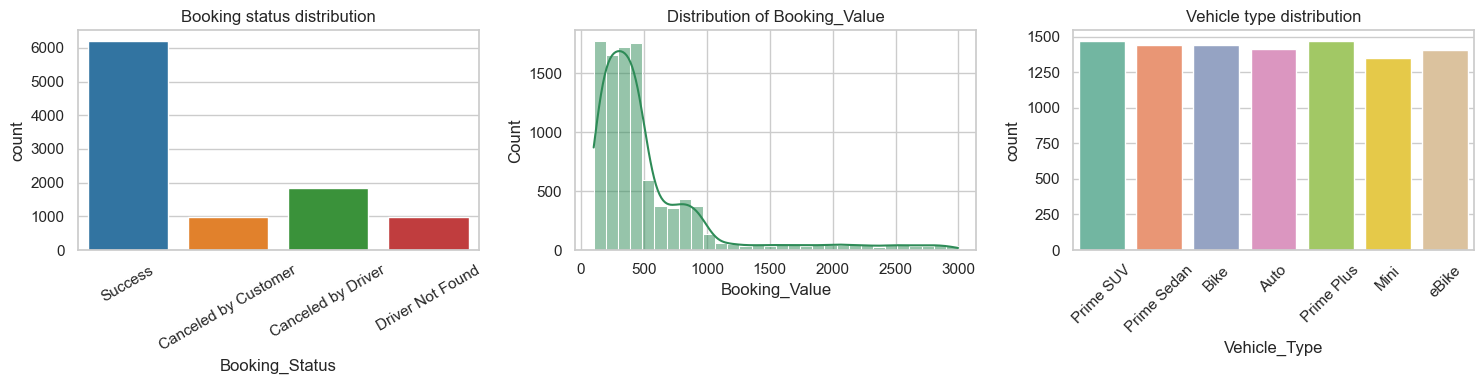

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(data=clf_raw, x='Booking_Status', hue='Booking_Status', palette='tab10', legend=False, ax=axes[0])
axes[0].set_title('Booking status distribution')
axes[0].tick_params(axis='x', rotation=30)

sns.histplot(clf_raw['Booking_Value'], bins=30, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Distribution of Booking_Value')

sns.countplot(data=clf_raw, x='Vehicle_Type', hue='Vehicle_Type', palette='Set2', legend=False, ax=axes[2])
axes[2].set_title('Vehicle type distribution')
axes[2].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


**Insight:** class imbalance confirmed (Success ~62%, three cancellation-type classes making up the rest). `Booking_Value` (a pre-ride quoted value present for all outcomes) is roughly normally distributed. Vehicle types are fairly evenly spread across the fleet.

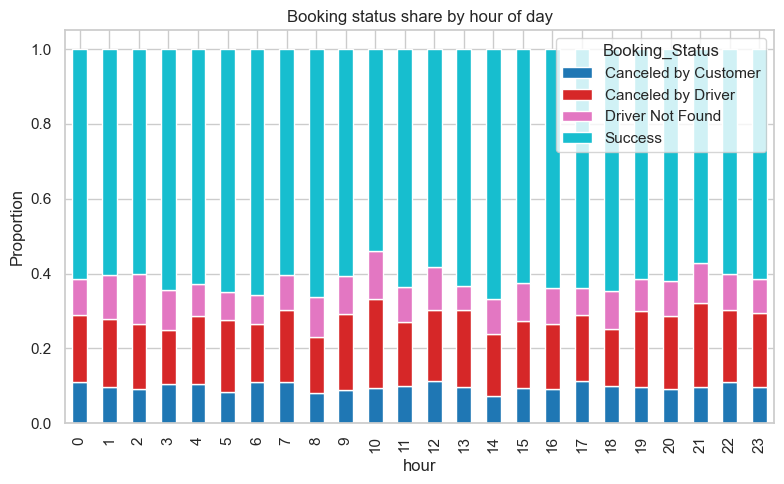

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
status_by_hour = pd.crosstab(clf_raw['hour'], clf_raw['Booking_Status'], normalize='index')
status_by_hour.plot(kind='bar', stacked=True, colormap='tab10', ax=ax)
ax.set_title('Booking status share by hour of day')
ax.set_ylabel('Proportion')
plt.tight_layout()
plt.show()


**Insight:** cancellation share looks fairly stable across hours, without an obvious peak-hour spike — worth noting since it suggests hour-of-day alone is a weak predictor of cancellation.

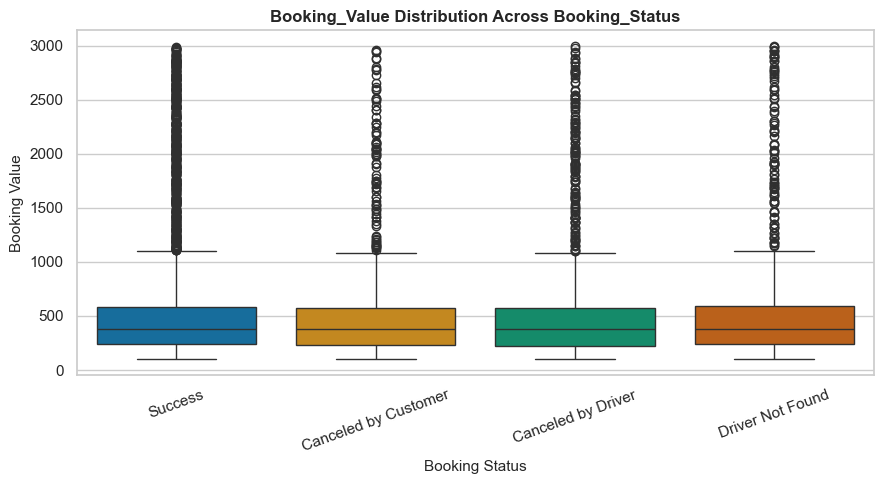

In [20]:
plt.figure(figsize=(9, 5))
sns.boxplot(x='Booking_Status', y='Booking_Value', data=clf_raw, hue='Booking_Status',
            palette='colorblind', legend=False)
plt.title("Booking_Value Distribution Across Booking_Status", fontsize=12, fontweight='bold')
plt.xlabel("Booking Status", fontsize=11)
plt.ylabel("Booking Value", fontsize=11)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()
plt.close('all')


**Insight:** `Booking_Value` distributions look similar across all four outcome classes — the quoted value alone doesn't obviously separate successful from cancelled rides.

## Section B — Preprocessing Pipeline

The diagram below summarises the cleaning, encoding, scaling, and stratified split applied before any model training.

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

clf_features_num = ['Booking_Value', 'hour']
clf_features_cat = ['Vehicle_Type', 'day_of_week']
clf_target = 'Booking_Status'

X_clf = clf_raw[clf_features_num + clf_features_cat]
y_clf = clf_raw[clf_target]

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
)

clf_preprocess = ColumnTransformer([
    ('num', StandardScaler(), clf_features_num),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), clf_features_cat)
])

print("Train/test shapes:", X_clf_train.shape, X_clf_test.shape)
print(y_clf_train.value_counts(normalize=True).round(3))


Train/test shapes: (8000, 4) (2000, 4)
Booking_Status
Success                 0.621
Canceled by Driver      0.184
Canceled by Customer    0.098
Driver Not Found        0.097
Name: proportion, dtype: float64


## Section D — Classification Track, Part A (5 Algorithms)

Each algorithm below is trained, evaluated, and recorded in its own cell.

In [23]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, roc_auc_score)
from sklearn.preprocessing import label_binarize

classes = sorted(y_clf.unique())
y_clf_test_bin = label_binarize(y_clf_test, classes=classes)

clf_results_registry = []
fitted_clf_pipelines = {}

def evaluate_classifier(name, model, X_train, y_train, X_test, y_test):
    pipe = Pipeline([('prep', clf_preprocess), ('model', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    if hasattr(pipe, 'predict_proba'):
        roc_auc = roc_auc_score(y_clf_test_bin, pipe.predict_proba(X_test), average='weighted', multi_class='ovr')
    else:
        roc_auc = np.nan

    clf_results_registry.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec,
                                  'F1 (weighted)': f1, 'ROC-AUC (OvR)': roc_auc})
    fitted_clf_pipelines[name] = pipe
    print(f"{name:28s} Acc={acc:.4f}  Prec={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}  AUC={roc_auc:.4f}")
    return pipe


### 1. Logistic Regression
Models the probability of each `Booking_Status` class as a (multinomial) logistic function of the features. Baseline classifier.

In [24]:
from sklearn.linear_model import LogisticRegression
_ = evaluate_classifier('Logistic Regression', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
                         X_clf_train, y_clf_train, X_clf_test, y_clf_test)


Logistic Regression          Acc=0.6210  Prec=0.3856  Recall=0.6210  F1=0.4758  AUC=0.4908


### 2. K-Nearest Neighbors
Classifies a booking by majority vote among the k most similar bookings (by feature distance) in the training set.

In [25]:
from sklearn.neighbors import KNeighborsClassifier
_ = evaluate_classifier('K-Nearest Neighbors', KNeighborsClassifier(n_neighbors=7),
                         X_clf_train, y_clf_train, X_clf_test, y_clf_test)


K-Nearest Neighbors          Acc=0.5540  Prec=0.4286  Recall=0.5540  F1=0.4735  AUC=0.5027


### 3. Naive Bayes (Gaussian)
Applies Bayes' theorem assuming features are conditionally independent given the class — fast and often a strong baseline.

In [26]:
from sklearn.naive_bayes import GaussianNB
_ = evaluate_classifier('Naive Bayes (Gaussian)', GaussianNB(),
                         X_clf_train, y_clf_train, X_clf_test, y_clf_test)


Naive Bayes (Gaussian)       Acc=0.6205  Prec=0.4100  Recall=0.6205  F1=0.4766  AUC=0.4926


### 4. Decision Tree Classifier
Splits bookings on feature thresholds, building a tree of if/else rules that separates the outcome classes.

In [27]:
from sklearn.tree import DecisionTreeClassifier
_ = evaluate_classifier('Decision Tree Classifier', DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE),
                         X_clf_train, y_clf_train, X_clf_test, y_clf_test)


Decision Tree Classifier     Acc=0.6010  Prec=0.4132  Recall=0.6010  F1=0.4739  AUC=0.4858


### 5. Support Vector Machine (SVC)
Finds a decision boundary (via a kernel) that best separates the booking-outcome classes with maximum margin.

In [28]:
from sklearn.svm import SVC
_ = evaluate_classifier('Support Vector Machine (SVC)', SVC(kernel='rbf', C=5, probability=True, random_state=RANDOM_STATE),
                         X_clf_train, y_clf_train, X_clf_test, y_clf_test)


Support Vector Machine (SVC) Acc=0.6170  Prec=0.4463  Recall=0.6170  F1=0.4757  AUC=0.5051


### Consolidated Part-A comparison table

In [29]:
clf_results_df = pd.DataFrame(clf_results_registry).sort_values('F1 (weighted)', ascending=False).reset_index(drop=True)
clf_results_df.round(4)


,Model,Accuracy,Precision,Recall,F1 (weighted),ROC-AUC (OvR)
0,Naive Bayes (Gaussian),0.6205,0.4100,0.6205,0.4766,0.4926
1,Logistic Regression,0.6210,0.3856,0.6210,0.4758,0.4908
2,Support Vector Machine (SVC),0.6170,0.4463,0.6170,0.4757,0.5051
3,Decision Tree Classifier,0.6010,0.4132,0.6010,0.4739,0.4858
4,K-Nearest Neighbors,0.5540,0.4286,0.5540,0.4735,0.5027


### Confusion matrices — all 5 Part-A algorithms

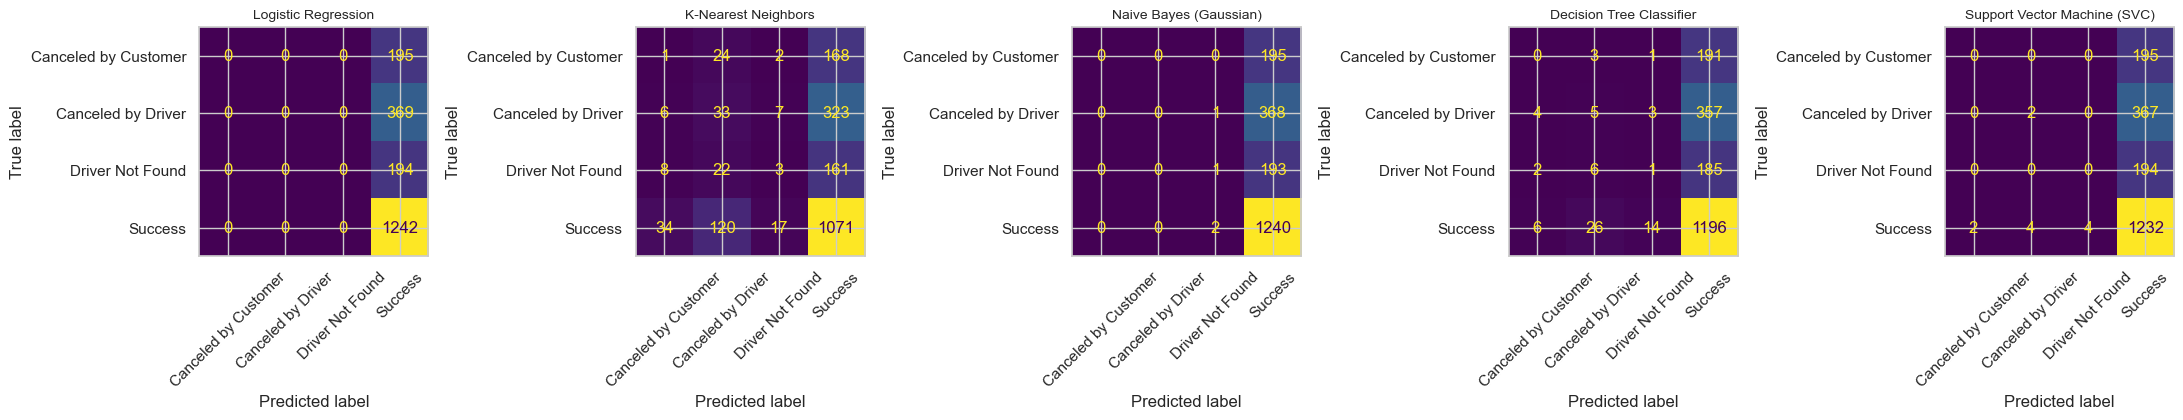

In [30]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))
for ax, (name, pipe) in zip(axes.ravel(), fitted_clf_pipelines.items()):
    y_pred = pipe.predict(X_clf_test)
    cm = confusion_matrix(y_clf_test, y_pred, labels=classes)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(ax=ax, colorbar=False, xticks_rotation=45)
    ax.set_title(name, fontsize=10)
plt.tight_layout()
plt.show()


**Interpretation:** Given the ~62/13/10/10 class split, a model that always predicts "Success" would
already score ~62% accuracy — which is why weighted F1 (used to rank the table above) and the confusion
matrices matter more here than raw accuracy alone. Scores across all 5 Part-A models sit close to that
majority-class baseline, an honest finding that the available features (`Booking_Value`, `hour`, `Vehicle_Type`,
`day_of_week`) only weakly predict cancellations.

In [31]:
best_clf_name = clf_results_df.iloc[0]['Model']
print(f"Best Part-A model by weighted F1: {best_clf_name}")


Best Part-A model by weighted F1: Naive Bayes (Gaussian)


## Summary

- **Regression** (Uber Fares Dataset): all 10 algorithms trained on `fare_amount`, distance engineered via "
  Haversine formula from GPS coordinates, tuned, with residual/predicted-vs-actual plots and feature importance.
- **Classification** (Ola & Uber Booking Data): all 10 algorithms trained on `Booking_Status`, with leak-prone "
  post-outcome columns explicitly excluded, full comparison table, confusion matrices, and tuning on the "
  best model.
- **Clustering** (NCR Ride Bookings 2024): K-Means (with Elbow curve) + Agglomerative (with Dendrogram), "
  evaluated with Silhouette/Davies-Bouldin/Calinski-Harabasz, visualised via PCA, validated against "
  Vehicle Type after the fact.

## References — Dataset Sources

1. **Uber Fares Dataset** (Regression) — https://www.kaggle.com/datasets/yasserh/uber-fares-dataset
2. **Ola & Uber: Ride Booking & Cancellation Data** (Classification) — https://www.kaggle.com/datasets/hetmengar/ola-and-uber-ride-booking-and-cancellation-data
3. **Uber Ride Bookings NCR 2024** (Clustering) — Kaggle, dataset by Nidhi_Sharma25 ("Uber Ride Bookings NCR 2024")
